# VoxIntel — 11: Fixing the Error Taxonomy Pipeline

## Why this notebook exists

Notebook 09 introduced the **error taxonomy layer** of VoxIntel — the part that should explain *why* better ASR improves downstream intent understanding.

However, Notebook 10 showed that the current taxonomy outputs are invalid:

- every sample is labeled `no_error`
- every alignment summary is `exact_match`
- yet the baseline and fine-tuned transcripts visibly differ from the ground-truth transcript in a large majority of rows

That means the error taxonomy stage is failing *before* interpretation begins.

This notebook exists to **repair** that stage.

---

## Research context

The purpose of an error taxonomy is not just to count ASR mistakes. It is to connect three layers:

1. **Surface transcription errors**
2. **Semantic distortion**
3. **Downstream intent failure**

In other words, VoxIntel does not only care about:

> how many words were wrong

It cares about:

> which kinds of wrong words actually changed system behavior

This notebook therefore has two roles:

- a **debugging role**: make the taxonomy pipeline technically correct
- a **research role**: make the interpretation layer scientifically defensible

---

## High-level goals

By the end of this notebook, we want to produce a corrected taxonomy dataset where:

- transcripts that differ from ground truth are **not** labeled `no_error`
- alignment summaries reflect real edit operations
- primary error types include a meaningful mix of:
  - substitution
  - insertion
  - deletion
  - number error
  - proper noun error
  - entity error
  - homophone-like error
  - mixed error
- downstream failure rates can be computed per error type
- failure-gallery examples become interpretable and believable

---

## Methodological note

This taxonomy is still a **rule-based heuristic analysis**, not a gold linguistic annotation.

That is acceptable for VoxIntel if we are careful in how we describe it:

- good for identifying patterns
- good for prioritizing error types
- not a claim of perfect semantic parsing

We will therefore explicitly validate the taxonomy with sanity checks before trusting any resulting plot or table.


## Cell 0 — Make sure `src` is importable


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports

We keep the dependency stack light and interpretable:

- `pandas` / `numpy` for table operations
- `difflib.SequenceMatcher` for token alignment
- `re` for deterministic tokenization
- `matplotlib` / `seaborn` for visual validation

No model training happens here.


In [2]:
import json
import math
import random
import re
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Cell 2 — Paths and outputs

This notebook reads the validated outputs from Notebook 08 and writes a **new corrected taxonomy version**.

We intentionally save to separate filenames so you can compare old vs fixed outputs.


In [3]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

ERROR_PROPAGATION_RESULTS_PATH = REPORTS_DIR / "error_propagation_results.csv"
FIXED_ERROR_TAXONOMY_PATH = REPORTS_DIR / "error_taxonomy_dataset_fixed.csv"
FIXED_ERROR_TYPE_DISTRIBUTION_PATH = REPORTS_DIR / "error_type_distribution_fixed.csv"
FIXED_ERROR_IMPACT_MATRIX_PATH = REPORTS_DIR / "error_impact_matrix_fixed.csv"
FIXED_INTENT_FRAGILITY_PATH = REPORTS_DIR / "intent_fragility_fixed.csv"
FIXED_FAILURE_GALLERY_PATH = REPORTS_DIR / "failure_gallery_fixed.csv"
FIXED_RECOVERY_SUMMARY_PATH = REPORTS_DIR / "recovery_summary_fixed.csv"

print("Reading from:", ERROR_PROPAGATION_RESULTS_PATH)
print("Saving fixed outputs to:", REPORTS_DIR)


Reading from: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\error_propagation_results.csv
Saving fixed outputs to: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports


## Cell 3 — Load the Notebook 08 propagation dataset


In [4]:
if not ERROR_PROPAGATION_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {ERROR_PROPAGATION_RESULTS_PATH}. Run Notebook 08 first."
    )

taxonomy_df = pd.read_csv(ERROR_PROPAGATION_RESULTS_PATH)
print(taxonomy_df.shape)
print(taxonomy_df.columns.tolist())
display(taxonomy_df.head())


(8688, 12)
['intent', 'scenario', 'ground_truth', 'baseline_transcript', 'finetuned_transcript', 'gt_pred', 'baseline_pred', 'finetuned_pred', 'baseline_correct', 'finetuned_correct', 'baseline_confidence', 'finetuned_confidence']


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,gt_pred,baseline_pred,finetuned_pred,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence
0,qa_currency,qa,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,general_quirky,qa_definition,False,False,0.571965,0.929527
1,qa_currency,qa,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,play_game,qa_definition,False,False,0.286248,0.841922
2,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.257733,0.991947
3,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.190725,0.991947
4,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.195282,0.991947


## Cell 4 — Validate required columns

The taxonomy layer should begin from Notebook 08 outputs, not from a previously-taxonomized file.

That avoids stale columns and duplicate-label issues.


In [5]:
required_columns = [
    "intent",
    "scenario",
    "ground_truth",
    "baseline_transcript",
    "finetuned_transcript",
    "baseline_pred",
    "finetuned_pred",
    "baseline_correct",
    "finetuned_correct",
    "baseline_confidence",
    "finetuned_confidence",
]

missing = [c for c in required_columns if c not in taxonomy_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns are present.")


All required columns are present.


## Cell 5 — Why Notebook 09 failed

Notebook 09 produced `no_error` for every row. That means the token comparison stage collapsed to an always-equal state.

Before rewriting the logic, we confirm the contradiction numerically:

- if transcripts differ, a correct taxonomy cannot emit only `no_error`
- if alignment always says `exact_match`, the alignment layer is broken


In [6]:
baseline_diff_rate = (taxonomy_df["baseline_transcript"].astype(str).str.lower() != taxonomy_df["ground_truth"].astype(str).str.lower()).mean()
finetuned_diff_rate = (taxonomy_df["finetuned_transcript"].astype(str).str.lower() != taxonomy_df["ground_truth"].astype(str).str.lower()).mean()

print(f"Baseline transcript differs from ground truth in {baseline_diff_rate:.4%} of rows")
print(f"Fine-tuned transcript differs from ground truth in {finetuned_diff_rate:.4%} of rows")


Baseline transcript differs from ground truth in 93.4968% of rows
Fine-tuned transcript differs from ground truth in 78.7983% of rows


## Cell 6 — New tokenization design

A good alignment tokenizer for this task should be:

- deterministic
- lowercasing for alignment stability
- punctuation-insensitive for word-level analysis
- simple enough to debug manually

We therefore tokenize with a regex word pattern and keep a separate raw-token path only for limited heuristics like proper-noun detection.


In [7]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")
NUMBER_RE = re.compile(r"\d+|zero|one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve", re.IGNORECASE)
STOPWORDS = {
    "a", "an", "the", "to", "of", "for", "in", "on", "at", "my", "your", "is", "are", "was", "were",
    "please", "me", "some", "and", "or", "with", "from", "do", "did", "be", "have", "has"
}


def normalize_spaces(text):
    return re.sub(r"\s+", " ", str(text)).strip()


def tokenize_for_alignment(text):
    return TOKEN_RE.findall(normalize_spaces(text).lower())


def tokenize_raw_words(text):
    return normalize_spaces(text).split()


def is_number_token(token):
    return bool(NUMBER_RE.fullmatch(str(token)))


def is_proper_noun_like(raw_token):
    raw_token = str(raw_token)
    return len(raw_token) > 0 and raw_token[0].isupper()


def lexical_overlap_ratio(a_tokens, b_tokens):
    if not a_tokens and not b_tokens:
        return 1.0
    if not a_tokens or not b_tokens:
        return 0.0
    a_set = set(a_tokens)
    b_set = set(b_tokens)
    return len(a_set & b_set) / len(a_set | b_set)


## Cell 7 — Theory: primary error type vs auxiliary flags

A single utterance can contain multiple error properties at once.

Example:
- a substitution that also affects a number
- a deletion inside a named entity
- a multi-edit phrase that changes a location name

So we separate:

### Primary error type
A single label chosen for summary tables and plots.

### Auxiliary flags
Boolean properties such as:
- `contains_number_error`
- `contains_proper_noun_error`
- `contains_entity_error`
- `contains_homophone_like_error`

This makes the taxonomy more interpretable without pretending that each row has only one semantic property.


## Cell 8 — Rewritten alignment-based error analyzer


In [8]:
def analyze_transcript_error(ground_truth_text, hypothesis_text):
    gt_raw_tokens = tokenize_raw_words(ground_truth_text)
    hyp_raw_tokens = tokenize_raw_words(hypothesis_text)
    gt_tokens = tokenize_for_alignment(ground_truth_text)
    hyp_tokens = tokenize_for_alignment(hypothesis_text)

    if gt_tokens == hyp_tokens:
        return {
            "primary_error_type": "no_error",
            "edit_pattern": "equal",
            "n_substitutions": 0,
            "n_insertions": 0,
            "n_deletions": 0,
            "n_total_edits": 0,
            "lexical_overlap": 1.0,
            "contains_number_error": False,
            "contains_proper_noun_error": False,
            "contains_entity_error": False,
            "contains_homophone_like_error": False,
            "alignment_summary": "exact_match",
        }

    matcher = SequenceMatcher(None, gt_tokens, hyp_tokens)

    n_substitutions = 0
    n_insertions = 0
    n_deletions = 0
    contains_number_error = False
    contains_proper_noun_error = False
    contains_entity_error = False
    contains_homophone_like_error = False
    edit_kinds = []
    summaries = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            continue

        gt_seg = gt_tokens[i1:i2]
        hyp_seg = hyp_tokens[j1:j2]
        gt_seg_raw = gt_raw_tokens[i1:i2] if i2 <= len(gt_raw_tokens) else gt_seg
        hyp_seg_raw = hyp_raw_tokens[j1:j2] if j2 <= len(hyp_raw_tokens) else hyp_seg

        if tag == "replace":
            n_substitutions += max(len(gt_seg), len(hyp_seg))
            edit_kinds.append("substitution")
            summaries.append(f"replace:{' '.join(gt_seg)}->{' '.join(hyp_seg)}")
        elif tag == "delete":
            n_deletions += len(gt_seg)
            edit_kinds.append("deletion")
            summaries.append(f"delete:{' '.join(gt_seg)}")
        elif tag == "insert":
            n_insertions += len(hyp_seg)
            edit_kinds.append("insertion")
            summaries.append(f"insert:{' '.join(hyp_seg)}")

        combined_tokens = list(gt_seg) + list(hyp_seg)
        combined_raw = list(gt_seg_raw) + list(hyp_seg_raw)

        if any(is_number_token(tok) for tok in combined_tokens):
            contains_number_error = True
        if any(is_proper_noun_like(tok) for tok in combined_raw):
            contains_proper_noun_error = True
        if any(tok not in STOPWORDS and tok.isalpha() and len(tok) > 2 for tok in combined_tokens):
            contains_entity_error = True
        if tag == "replace" and len(gt_seg) == 1 and len(hyp_seg) == 1:
            a = gt_seg[0]
            b = hyp_seg[0]
            if abs(len(a) - len(b)) <= 2 and SequenceMatcher(None, a, b).ratio() >= 0.6:
                contains_homophone_like_error = True

    n_total_edits = n_substitutions + n_insertions + n_deletions

    # Priority order matters. We move entity_error ABOVE generic fallback,
    # unlike the old broken notebook where entity_error was effectively unreachable.
    if contains_number_error:
        primary_error_type = "number_error"
    elif contains_proper_noun_error:
        primary_error_type = "proper_noun_error"
    elif contains_homophone_like_error:
        primary_error_type = "homophone_like_error"
    elif contains_entity_error:
        primary_error_type = "entity_error"
    elif len(set(edit_kinds)) > 1:
        primary_error_type = "mixed_error"
    elif edit_kinds:
        primary_error_type = edit_kinds[0]
    else:
        primary_error_type = "mixed_error"

    return {
        "primary_error_type": primary_error_type,
        "edit_pattern": "+".join(sorted(set(edit_kinds))) if edit_kinds else "equal",
        "n_substitutions": int(n_substitutions),
        "n_insertions": int(n_insertions),
        "n_deletions": int(n_deletions),
        "n_total_edits": int(n_total_edits),
        "lexical_overlap": lexical_overlap_ratio(gt_tokens, hyp_tokens),
        "contains_number_error": bool(contains_number_error),
        "contains_proper_noun_error": bool(contains_proper_noun_error),
        "contains_entity_error": bool(contains_entity_error),
        "contains_homophone_like_error": bool(contains_homophone_like_error),
        "alignment_summary": " | ".join(summaries[:5]) if summaries else "exact_match",
    }


## Cell 9 — Unit-style sanity checks on the analyzer

Before applying the taxonomy to thousands of rows, we test it on a few handcrafted examples.

A taxonomy function that fails here should not be trusted at dataset scale.


In [9]:
examples = [
    ("how many unread emails do i have", "HOW MANY A RED AMALS DO I HAVE"),
    ("remove pepper from my grocery list", "REMOVE PABOT FROM MY GROCTERE LIST"),
    ("wake me up at ten", "WAKE ME UP AT TEN"),
    ("call John tomorrow", "CALL JOAN TOMORROW"),
    ("set alarm for four", "SET ALARM FOR FOR"),
]

example_rows = []
for gt, hyp in examples:
    row = analyze_transcript_error(gt, hyp)
    row["ground_truth"] = gt
    row["hypothesis"] = hyp
    example_rows.append(row)

example_debug_df = pd.DataFrame(example_rows)
display(example_debug_df[[
    "ground_truth", "hypothesis", "primary_error_type", "edit_pattern",
    "n_total_edits", "lexical_overlap", "alignment_summary"
]])


,ground_truth,hypothesis,primary_error_type,edit_pattern,n_total_edits,lexical_overlap,alignment_summary
0,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,proper_noun_error,substitution,3,0.50,replace:unread emails->a red amals
1,remove pepper from my grocery list,REMOVE PABOT FROM MY GROCTERE LIST,proper_noun_error,substitution,2,0.50,replace:pepper->pabot | replace:grocery->groctere
2,wake me up at ten,WAKE ME UP AT TEN,no_error,equal,0,1.00,exact_match
3,call John tomorrow,CALL JOAN TOMORROW,proper_noun_error,substitution,1,0.50,replace:john->joan
4,set alarm for four,SET ALARM FOR FOR,number_error,substitution,1,0.75,replace:four->for


## Cell 10 — Apply the repaired analyzer to baseline and fine-tuned transcripts

We always derive the taxonomy from the clean Notebook 08 propagation results.
This avoids stale columns and makes reruns safe.


In [10]:
baseline_rows = []
finetuned_rows = []

for _, row in taxonomy_df.iterrows():
    baseline_rows.append(analyze_transcript_error(row["ground_truth"], row["baseline_transcript"]))
    finetuned_rows.append(analyze_transcript_error(row["ground_truth"], row["finetuned_transcript"]))

baseline_error_df = pd.DataFrame(baseline_rows).add_prefix("baseline_")
finetuned_error_df = pd.DataFrame(finetuned_rows).add_prefix("finetuned_")

fixed_taxonomy_df = pd.concat([
    taxonomy_df.reset_index(drop=True),
    baseline_error_df.reset_index(drop=True),
    finetuned_error_df.reset_index(drop=True),
], axis=1)

print(fixed_taxonomy_df.shape)
display(fixed_taxonomy_df.head())


(8688, 36)


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,gt_pred,baseline_pred,finetuned_pred,baseline_correct,finetuned_correct,...,finetuned_n_substitutions,finetuned_n_insertions,finetuned_n_deletions,finetuned_n_total_edits,finetuned_lexical_overlap,finetuned_contains_number_error,finetuned_contains_proper_noun_error,finetuned_contains_entity_error,finetuned_contains_homophone_like_error,finetuned_alignment_summary
0,qa_currency,qa,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,general_quirky,qa_definition,False,False,...,3,0,0,3,0.500000,False,True,True,False,replace:dollar in->dolar and | replace:yen->ian
1,qa_currency,qa,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,play_game,qa_definition,False,False,...,4,0,0,4,0.416667,False,True,True,True,replace:siri->seri | replace:dollar->dolar | r...
2,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,...,0,0,0,0,1.000000,False,False,False,False,exact_match
3,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,...,0,0,0,0,1.000000,False,False,False,False,exact_match
4,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,...,0,0,0,0,1.000000,False,False,False,False,exact_match


## Cell 11 — Immediate post-fix sanity checks

These are the most important validation checks in the notebook.

If they fail, stop here and do not trust later plots.


In [11]:
postfix_sanity = {
    "baseline_no_error_rate": float((fixed_taxonomy_df["baseline_primary_error_type"] == "no_error").mean()),
    "finetuned_no_error_rate": float((fixed_taxonomy_df["finetuned_primary_error_type"] == "no_error").mean()),
    "baseline_exact_match_rate": float((fixed_taxonomy_df["baseline_alignment_summary"] == "exact_match").mean()),
    "finetuned_exact_match_rate": float((fixed_taxonomy_df["finetuned_alignment_summary"] == "exact_match").mean()),
    "baseline_diff_rate": float((fixed_taxonomy_df["baseline_transcript"].astype(str).str.lower() != fixed_taxonomy_df["ground_truth"].astype(str).str.lower()).mean()),
    "finetuned_diff_rate": float((fixed_taxonomy_df["finetuned_transcript"].astype(str).str.lower() != fixed_taxonomy_df["ground_truth"].astype(str).str.lower()).mean()),
}

postfix_sanity


{'baseline_no_error_rate': 0.06503222836095764,
 'finetuned_no_error_rate': 0.2121316758747698,
 'baseline_exact_match_rate': 0.06503222836095764,
 'finetuned_exact_match_rate': 0.2121316758747698,
 'baseline_diff_rate': 0.9349677716390423,
 'finetuned_diff_rate': 0.7879834254143646}

## Cell 12 — Build downstream impact labels again

The taxonomy becomes meaningful only when it is connected to intent success/failure.

We therefore rebuild the impact labels using the same rule as Notebook 09:

- `high_impact` if the intent is wrong
- `no_error` if transcript matches exactly and intent is correct
- `low_impact` otherwise


In [12]:
fixed_taxonomy_df["baseline_intent_failure"] = ~fixed_taxonomy_df["baseline_correct"].astype(bool)
fixed_taxonomy_df["finetuned_intent_failure"] = ~fixed_taxonomy_df["finetuned_correct"].astype(bool)

fixed_taxonomy_df["baseline_impact"] = np.where(
    fixed_taxonomy_df["baseline_intent_failure"],
    "high_impact",
    np.where(fixed_taxonomy_df["baseline_primary_error_type"] == "no_error", "no_error", "low_impact")
)
fixed_taxonomy_df["finetuned_impact"] = np.where(
    fixed_taxonomy_df["finetuned_intent_failure"],
    "high_impact",
    np.where(fixed_taxonomy_df["finetuned_primary_error_type"] == "no_error", "no_error", "low_impact")
)

display(fixed_taxonomy_df[[
    "ground_truth", "baseline_transcript", "baseline_primary_error_type", "baseline_impact",
    "finetuned_transcript", "finetuned_primary_error_type", "finetuned_impact"
]].head(10))


,ground_truth,baseline_transcript,baseline_primary_error_type,baseline_impact,finetuned_transcript,finetuned_primary_error_type,finetuned_impact
0,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,proper_noun_error,high_impact,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,proper_noun_error,high_impact
1,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,proper_noun_error,high_impact,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,proper_noun_error,high_impact
2,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,proper_noun_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
3,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,proper_noun_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
4,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,proper_noun_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
5,how many unread emails do i have,HOW MANY HUNDRED GUINOTS DO I HAVE,proper_noun_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
6,how many unread emails do i have,HOW MANY ANRITIN IMALES DO I HAVE,proper_noun_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
7,how many unread emails do i have,HOW MYI ANGREAT HEMORGE DOR AHEAD,proper_noun_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
8,order me chinese food,OR DE MICINESE FOUD,proper_noun_error,high_impact,ORDER ME CHINESE FOD,proper_noun_error,low_impact
9,order me chinese food,ORDINY CHINESE FOOD,proper_noun_error,low_impact,ORDER ME CHINESE FOD,proper_noun_error,low_impact


## Cell 13 — Error type distribution (fixed)

This is the first place where we should see whether the repair succeeded.
A valid taxonomy should show a nontrivial mixture of error types.


In [13]:
error_type_distribution_fixed_df = pd.DataFrame({
    "baseline": fixed_taxonomy_df["baseline_primary_error_type"].value_counts(),
    "finetuned": fixed_taxonomy_df["finetuned_primary_error_type"].value_counts(),
}).fillna(0).astype(int).reset_index().rename(columns={"index": "error_type"})

error_type_distribution_fixed_df["delta_finetuned_minus_baseline"] = (
    error_type_distribution_fixed_df["finetuned"] - error_type_distribution_fixed_df["baseline"]
)

display(error_type_distribution_fixed_df.sort_values("baseline", ascending=False))


,error_type,baseline,finetuned,delta_finetuned_minus_baseline
4,proper_noun_error,7573,6487,-1086
2,no_error,565,1843,1278
3,number_error,488,253,-235
1,entity_error,43,46,3
0,deletion,19,59,40


## Cell 14 — Error impact matrix (fixed)

This matrix estimates which primary error types are associated with the highest downstream failure rates.

Interpretation rule:
- high sample count + high failure rate = likely priority error type
- low sample count + high failure rate = interesting but noisy


In [14]:
def build_error_impact_matrix(df, prefix):
    rows = []
    for error_type, group in df.groupby(f"{prefix}_primary_error_type"):
        rows.append({
            "system": prefix,
            "error_type": error_type,
            "samples": len(group),
            "intent_failure_rate": float(group[f"{prefix}_intent_failure"].mean()),
            "low_impact_rate": float((group[f"{prefix}_impact"] == "low_impact").mean()),
            "mean_edits": float(group[f"{prefix}_n_total_edits"].mean()),
            "mean_overlap": float(group[f"{prefix}_lexical_overlap"].mean()),
        })
    return pd.DataFrame(rows)

error_impact_matrix_fixed_df = pd.concat([
    build_error_impact_matrix(fixed_taxonomy_df, "baseline"),
    build_error_impact_matrix(fixed_taxonomy_df, "finetuned"),
], ignore_index=True)

display(error_impact_matrix_fixed_df.sort_values(["system", "intent_failure_rate"], ascending=[True, False]))


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
3,baseline,number_error,488,0.682377,0.317623,6.598361,0.229696
4,baseline,proper_noun_error,7573,0.645451,0.354549,4.054008,0.302066
0,baseline,deletion,19,0.210526,0.789474,1.105263,0.787425
2,baseline,no_error,565,0.203540,0.000000,0.000000,1.000000
1,baseline,entity_error,43,0.093023,0.906977,1.325581,0.722733
9,finetuned,proper_noun_error,6487,0.298289,0.701711,2.310775,0.529471
8,finetuned,number_error,253,0.288538,0.711462,3.861660,0.488153
7,finetuned,no_error,1843,0.158980,0.000000,0.000000,1.000000
5,finetuned,deletion,59,0.084746,0.915254,1.084746,0.796427
6,finetuned,entity_error,46,0.043478,0.956522,1.152174,0.769953


## Cell 15 — Intent fragility (fixed)

This table should now be interpreted more carefully than the older Notebook 08 version.

It is based directly on baseline/fine-tuned correctness rates by intent, not on the broken taxonomy labels from old Notebook 09.


In [15]:
intent_fragility_fixed_df = (
    fixed_taxonomy_df.groupby("intent")
    .agg(
        n_samples=("intent", "size"),
        baseline_failure_rate=("baseline_intent_failure", "mean"),
        finetuned_failure_rate=("finetuned_intent_failure", "mean"),
        baseline_mean_edits=("baseline_n_total_edits", "mean"),
        finetuned_mean_edits=("finetuned_n_total_edits", "mean"),
    )
    .reset_index()
)
intent_fragility_fixed_df["recovery_rate"] = (
    intent_fragility_fixed_df["baseline_failure_rate"] - intent_fragility_fixed_df["finetuned_failure_rate"]
)
intent_fragility_fixed_df = intent_fragility_fixed_df.sort_values("baseline_failure_rate", ascending=False).reset_index(drop=True)

display(intent_fragility_fixed_df.head(20))


,intent,n_samples,baseline_failure_rate,finetuned_failure_rate,baseline_mean_edits,finetuned_mean_edits,recovery_rate
0,cooking_query,14,1.000000,1.000000,1.214286,1.357143,0.000000
1,cleaning,8,1.000000,1.000000,5.125000,1.625000,0.000000
2,general_greet,17,1.000000,1.000000,2.058824,0.823529,0.000000
3,factoid,14,1.000000,1.000000,2.714286,1.285714,0.000000
4,hue_lightup,1,1.000000,1.000000,4.000000,1.000000,0.000000
5,podcasts,6,1.000000,1.000000,2.833333,0.833333,0.000000
6,post,2,1.000000,1.000000,3.500000,2.000000,0.000000
7,music_dislikeness,5,1.000000,1.000000,2.600000,1.400000,0.000000
8,greet,2,1.000000,1.000000,0.500000,0.000000,0.000000
9,hue_lightoff,9,1.000000,1.000000,3.444444,1.111111,0.000000


## Cell 16 — Recovery-status reconstruction

We keep the same recovery logic as before so the new taxonomy remains directly comparable to Notebook 08.


In [16]:
recovery_conditions = [
    (~fixed_taxonomy_df["baseline_correct"]) & (fixed_taxonomy_df["finetuned_correct"]),
    (fixed_taxonomy_df["baseline_correct"]) & (~fixed_taxonomy_df["finetuned_correct"]),
    (~fixed_taxonomy_df["baseline_correct"]) & (~fixed_taxonomy_df["finetuned_correct"]),
    (fixed_taxonomy_df["baseline_correct"]) & (fixed_taxonomy_df["finetuned_correct"]),
]
recovery_labels = ["recovered", "regressed", "still_broken", "always_correct"]

fixed_taxonomy_df["recovery_status"] = np.select(recovery_conditions, recovery_labels, default="unknown")

recovery_summary_fixed_df = fixed_taxonomy_df["recovery_status"].value_counts(dropna=False).rename_axis("recovery_status").reset_index(name="samples")
recovery_summary_fixed_df["rate"] = recovery_summary_fixed_df["samples"] / len(fixed_taxonomy_df)

display(recovery_summary_fixed_df)


,recovery_status,samples,rate
0,recovered,3430,0.394797
1,always_correct,2950,0.339549
2,still_broken,1914,0.220304
3,regressed,394,0.045350


## Cell 17 — Failure gallery (fixed)

This gallery is one of the most human-readable outputs in the project.

We want it to show real, interpretable examples where:
- the baseline ASR fails
- the fine-tuned ASR recovers
- or both still fail


In [17]:
failure_gallery_fixed_df = fixed_taxonomy_df.loc[
    fixed_taxonomy_df["baseline_intent_failure"] | fixed_taxonomy_df["finetuned_intent_failure"],
    [
        "intent", "scenario", "ground_truth", "baseline_transcript", "finetuned_transcript",
        "baseline_primary_error_type", "finetuned_primary_error_type",
        "baseline_impact", "finetuned_impact",
        "baseline_correct", "finetuned_correct",
        "baseline_confidence", "finetuned_confidence",
        "baseline_alignment_summary", "finetuned_alignment_summary",
        "recovery_status",
    ]
].copy()

failure_gallery_fixed_df = failure_gallery_fixed_df.sort_values(
    ["recovery_status", "baseline_impact", "finetuned_impact"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(failure_gallery_fixed_df.head(30))


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,baseline_primary_error_type,finetuned_primary_error_type,baseline_impact,finetuned_impact,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence,baseline_alignment_summary,finetuned_alignment_summary,recovery_status
0,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,proper_noun_error,no_error,high_impact,no_error,False,True,0.257733,0.991947,replace:unread emails->a red amals,exact_match,recovered
1,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,proper_noun_error,no_error,high_impact,no_error,False,True,0.190725,0.991947,replace:unread emails do->an red omin us to,exact_match,recovered
2,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,proper_noun_error,no_error,high_impact,no_error,False,True,0.195282,0.991947,replace:unread emails->undred enols,exact_match,recovered
3,email_query,email,how many unread emails do i have,HOW MANY HUNDRED GUINOTS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,proper_noun_error,no_error,high_impact,no_error,False,True,0.951244,0.991947,replace:unread emails->hundred guinots,exact_match,recovered
4,email_query,email,how many unread emails do i have,HOW MANY ANRITIN IMALES DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,proper_noun_error,no_error,high_impact,no_error,False,True,0.504026,0.991947,replace:unread emails->anritin imales,exact_match,recovered
5,email_query,email,how many unread emails do i have,HOW MYI ANGREAT HEMORGE DOR AHEAD,HOW MANY UNREAD EMAILS DO I HAVE,proper_noun_error,no_error,high_impact,no_error,False,True,0.931720,0.991947,replace:many unread emails do i have->myi angr...,exact_match,recovered
6,takeaway_query,takeaway,does the nearby chinese restaurant do delivery,DOES THE NEARBY CHINESE RECON DUE DLIVERY,DOES THE NEARBY CHINESE RESTAURANT DO DELIVERY,proper_noun_error,no_error,high_impact,no_error,False,True,0.677121,0.968153,replace:restaurant do delivery->recon due dlivery,exact_match,recovered
7,alarm_set,alarm,wake me up at ten,WOT ME UP AT TELL,WAKE ME UP AT TEN,number_error,no_error,high_impact,no_error,False,True,0.788896,0.982779,replace:wake->wot | replace:ten->tell,exact_match,recovered
8,alarm_set,alarm,wake me up at ten,WOTE MI A AT DEN,WAKE ME UP AT TEN,number_error,no_error,high_impact,no_error,False,True,0.764333,0.982779,replace:wake me up->wote mi a | replace:ten->den,exact_match,recovered
9,alarm_set,alarm,wake me up at ten,WAY WE AR AFTENN,WAKE ME UP AT TEN,number_error,no_error,high_impact,no_error,False,True,0.957383,0.982779,replace:wake me up at ten->way we ar aftenn,exact_match,recovered


## Cell 18 — Visual validation: error type distribution

If the repair worked, this plot should no longer collapse into a single `no_error` bar.


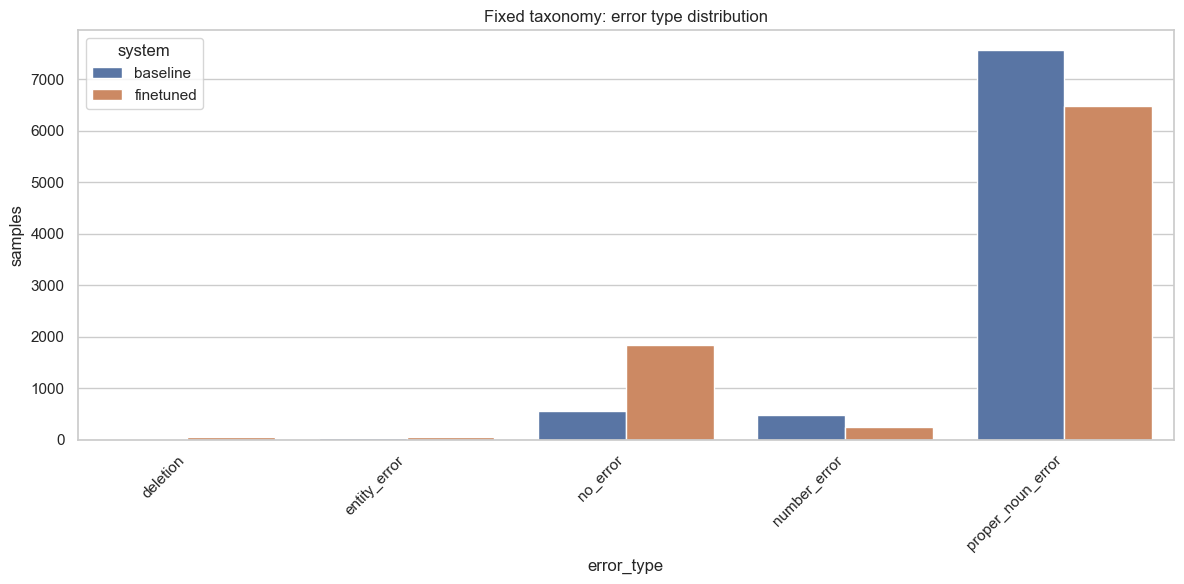

In [18]:
plot_df = error_type_distribution_fixed_df.melt(
    id_vars="error_type",
    value_vars=["baseline", "finetuned"],
    var_name="system",
    value_name="samples",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="error_type", y="samples", hue="system")
plt.xticks(rotation=45, ha="right")
plt.title("Fixed taxonomy: error type distribution")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "error_type_distribution_fixed.png", dpi=150)
plt.show()


## Cell 19 — Visual validation: impact by error type


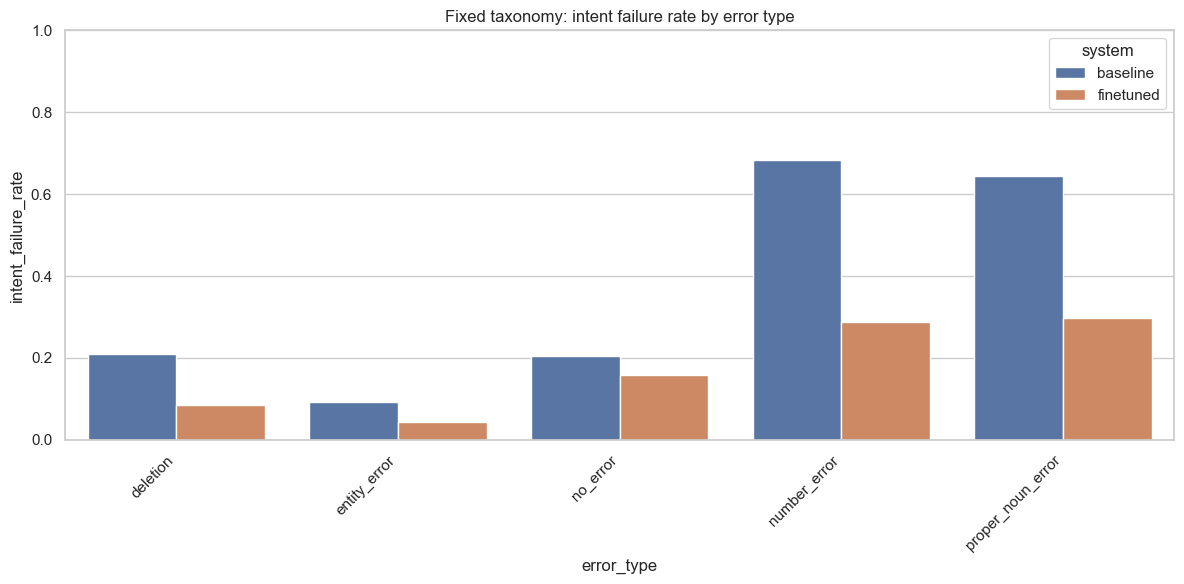

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=error_impact_matrix_fixed_df, x="error_type", y="intent_failure_rate", hue="system")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title("Fixed taxonomy: intent failure rate by error type")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "error_impact_matrix_fixed.png", dpi=150)
plt.show()


## Cell 20 — Visual validation: top fragile intents


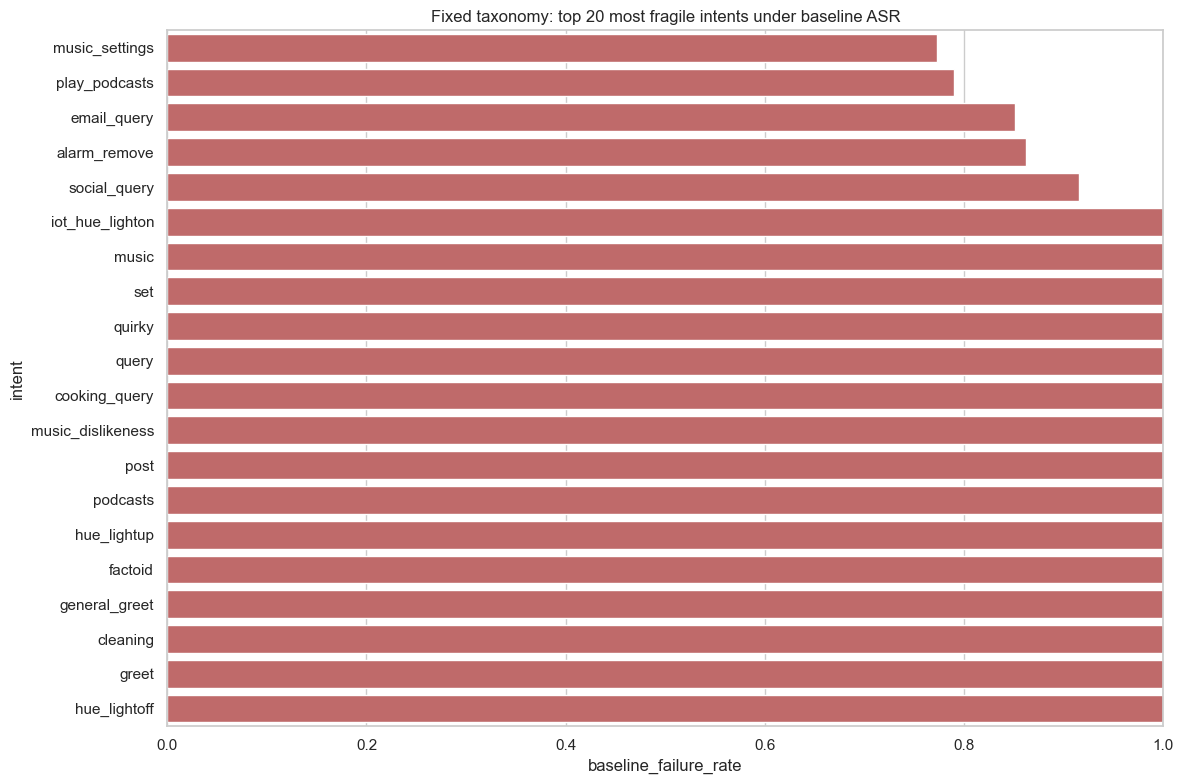

In [20]:
plot_fragility_df = intent_fragility_fixed_df.head(20).sort_values("baseline_failure_rate", ascending=True)
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_fragility_df, y="intent", x="baseline_failure_rate", color="indianred")
plt.xlim(0, 1.0)
plt.title("Fixed taxonomy: top 20 most fragile intents under baseline ASR")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "intent_fragility_fixed.png", dpi=150)
plt.show()


## Cell 21 — Final trust checks

We explicitly check whether the repaired outputs are now plausible.

A plausible repaired taxonomy should satisfy at least:

- not all rows are `no_error`
- not all rows are `exact_match`
- some rows contain substitutions / insertions / deletions / mixed errors


In [21]:
final_checks = {
    "baseline_has_multiple_error_types": error_type_distribution_fixed_df["error_type"].nunique() > 1,
    "baseline_no_error_not_all": (fixed_taxonomy_df["baseline_primary_error_type"] == "no_error").mean() < 0.99,
    "baseline_exact_match_not_all": (fixed_taxonomy_df["baseline_alignment_summary"] == "exact_match").mean() < 0.99,
    "finetuned_no_error_not_all": (fixed_taxonomy_df["finetuned_primary_error_type"] == "no_error").mean() < 0.99,
    "finetuned_exact_match_not_all": (fixed_taxonomy_df["finetuned_alignment_summary"] == "exact_match").mean() < 0.99,
}

final_checks


{'baseline_has_multiple_error_types': True,
 'baseline_no_error_not_all': True,
 'baseline_exact_match_not_all': True,
 'finetuned_no_error_not_all': True,
 'finetuned_exact_match_not_all': True}

## Cell 22 — Save corrected outputs


In [ ]:
fixed_taxonomy_df.to_csv(FIXED_ERROR_TAXONOMY_PATH, index=False)
error_type_distribution_fixed_df.to_csv(FIXED_ERROR_TYPE_DISTRIBUTION_PATH, index=False)
error_impact_matrix_fixed_df.to_csv(FIXED_ERROR_IMPACT_MATRIX_PATH, index=False)
intent_fragility_fixed_df.to_csv(FIXED_INTENT_FRAGILITY_PATH, index=False)
recovery_summary_fixed_df.to_csv(FIXED_RECOVERY_SUMMARY_PATH, index=False)
failure_gallery_fixed_df.to_csv(FIXED_FAILURE_GALLERY_PATH, index=False)

with open(REPORTS_DIR / "taxonomy_fix_summary.json", "w", encoding="utf-8") as f:

    json.dump(
        {
            "postfix_sanity": postfix_sanity,
            "final_checks": final_checks,
        },
        f,
        indent=2,
        default=lambda x: (
            bool(x) if isinstance(x, np.bool_)
            else int(x) if isinstance(x, np.integer)
            else float(x) if isinstance(x, np.floating)
            else str(x)
        ),
    )


## Cell 23 — Final interpretation

If the post-fix sanity checks pass, then Notebook 09 can be replaced by this repaired analysis.

At that point, VoxIntel has:

- a valid upper-bound classifier (07)
- a valid error-propagation experiment (08)
- a valid taxonomy/interpretation layer (11, replacing broken 09)

That gives you a complete and research-worthy story:

> Better ASR improves downstream intent understanding, and the effect can be explained through the reduction of specific high-impact transcription error types.


In [24]:
print("=" * 72)
print("FIXED ERROR TAXONOMY SUMMARY")
print("=" * 72)
print("Post-fix sanity:")
for k, v in postfix_sanity.items():
    print(f"- {k}: {v}")
print()
print("Final trust checks:")
for k, v in final_checks.items():
    print(f"- {k}: {v}")
print()
print(f"Saved fixed outputs to: {REPORTS_DIR}")

FIXED ERROR TAXONOMY SUMMARY
Post-fix sanity:
- baseline_no_error_rate: 0.06503222836095764
- finetuned_no_error_rate: 0.2121316758747698
- baseline_exact_match_rate: 0.06503222836095764
- finetuned_exact_match_rate: 0.2121316758747698
- baseline_diff_rate: 0.9349677716390423
- finetuned_diff_rate: 0.7879834254143646

Final trust checks:
- baseline_has_multiple_error_types: True
- baseline_no_error_not_all: True
- baseline_exact_match_not_all: True
- finetuned_no_error_not_all: True
- finetuned_exact_match_not_all: True

Saved fixed outputs to: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports
